# Does MATE Encoder learn which transition is actually informative?
Experimented with T-Maze

### Environment Loading

In [1]:
import yaml
class DotDict(dict):
    """d.a 처럼 접근 가능한 dict. 중첩도 재귀로 변환."""
    __getattr__ = dict.get
    __setattr__ = dict.__setitem__
    __delattr__ = dict.__delitem__

    def to_dict(self):
        def _plain(x):
            if isinstance(x, dict):
                return {k: _plain(v) for k, v in x.items()}
            if isinstance(x, list):
                return [_plain(v) for v in x]
            return x
        return _plain(self)

def to_dotdict(x):
    if isinstance(x, dict):
        return DotDict({k: to_dotdict(v) for k, v in x.items()})
    if isinstance(x, list):
        return [to_dotdict(v) for v in x]
    if isinstance(x, str) and 'e-' in x.lower():
            try:
                return float(x)
            except ValueError:
                pass
    return x

def unwrap_value_nodes(obj):
    if isinstance(obj, dict):
        if set(obj.keys()) == {"value"}:
            return unwrap_value_nodes(obj["value"])
        return {k: unwrap_value_nodes(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [unwrap_value_nodes(x) for x in obj]
    return obj

def load_cfg(config_path):
    with open(config_path, "r", encoding="utf-8") as f:
        raw = yaml.safe_load(f)

    raw = unwrap_value_nodes(raw)

    # 필요한 3개만 추출
    picked = {k: raw[k] for k in ["config_env", "config_rl", "config_seq"]}

    # 점 접근 가능하게 변환
    return to_dotdict(picked)

Modify here to change directory

In [2]:
import os

log_dir = "./logs/tmaze_active/100/test_gate_2026-03-11-15:41:07" # Example: "logs/mujoco/ant-dir/run_name_2026-01-05-17:27:32"
if log_dir == "SET_YOUR_LOG_DIR_HERE":
    raise ValueError("Please set the 'log_dir' variable to your actual log directory path.")

config_dir = os.path.join(log_dir, "wandb/latest-run/files/config.yaml")

cfg = load_cfg(config_dir)
config_env = cfg.config_env
config_rl = cfg.config_rl
config_seq = cfg.config_seq
print("Environment Config:", config_env)
print("RL Config:", config_rl)
print("Sequence Model Config:", config_seq)

Environment Config: {'env_name': 100, 'env_type': 'tmaze_active', 'eval_episodes': 64, 'eval_interval': 256, 'horizon': 'finite', 'log_interval': 128, 'n_env': 64, 'normalize_transitions': False, 'terminate_after_success': True, 'visualize_env': False, 'visualize_every': 5}
RL Config: {'algo': 'dqn', 'config_critic': {'hidden_dims': [256, 256]}, 'critic_lr': 3e-05, 'discount': 0.99, 'end_eps': 0.009708737864077669, 'init_eps': 1, 'replay_buffer_num_episodes': 10000, 'schedule_end': 0.1, 'schedule_steps': 824000, 'tau': 0.001}
Sequence Model Config: {'clip': True, 'embedder': {'hidden_sizes': [], 'norm': 'none', 'output_activation': 'leakyrelu', 'project_output': True}, 'full_transition': True, 'max_norm': 0.03, 'obs_shortcut': True, 'permutation_training': False, 'project_output': True, 'seq_model': {'hidden_size': 128, 'max_seq_length': 104, 'n_layer': 1, 'name': 'mate', 'pdrop': 0.1}, 'transition_dropout': 0}


In [3]:
import gymnasium as gym
from gymnasium.envs.registration import register
from torchkit.pytorch_utils import set_gpu_mode
env_name_fn = lambda l: f"tmaze_active_T-{l}"

seed = 42
gpu_id = 0
device = f'cuda:{gpu_id}'
set_gpu_mode(True, gpu_id)

length = config_env.env_name
env_name = env_name_fn(length)

# For Active T-Maze
register(
    env_name,
    entry_point="envs.tmaze:TMazeClassicActive", # 
    kwargs=dict(
        corridor_length=length,
        penalty=-1.0 / (length+2),  # NOTE: \sum_{t=1}^T -1/T = -1
    ),
    max_episode_steps=length + 2 * 1 + 1,  # NOTE: has to define it here
)

# # For Passive T-Maze
# register(
#     env_name,
#     entry_point="envs.tmaze:TMazeClassicPassive",
#     kwargs=dict(
#         corridor_length=length,
#         penalty=-1.0 / (length+1),  # NOTE: \sum_{t=1}^T -1/T = -1
#     ),
#     max_episode_steps=length + 1,  # NOTE: has to define it here
# )

env = gym.make(env_name)
env.max_episode_steps = getattr(
    env, "max_episode_steps", env.spec.max_episode_steps
)
env.reset(seed=seed) # Set random seed
env.action_space.seed(seed)
env.observation_space.seed(seed)

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

42

In [4]:
action_space = env.action_space
observation_space = env.observation_space

act_dim = action_space.n
obs_dim = observation_space.shape[0]

print("obs space", observation_space)
print("act space", action_space)
print("obs_dim", obs_dim, "act_dim", act_dim)

obs space Box(-1.0, 1.0, (3,), float32)
act space Discrete(4)
obs_dim 3 act_dim 4


### Load Policy

In [5]:
from policies.models.policy_rnn_dqn import ModelFreeOffPolicy_DQN_RNN as Policy_DQN_RNN
agent_class = Policy_DQN_RNN

agent = agent_class(
    obs_dim=obs_dim,
    action_dim=act_dim,
    config_seq=config_seq,
    config_rl=config_rl,
    freeze_critic=True,
).to(device)

/home/himchan/anaconda3/envs/metaworld/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sequence model options: obs_shortcut=True, full_transition=True, project_output=True
Use permutation training: False
Transition dropout: 0


In [6]:
import torch
agent_checkpoint_path = os.path.join(log_dir, "policy_checkpoint_latest.pth")
agent.load_state_dict(torch.load(agent_checkpoint_path, map_location=device))


<All keys matched successfully>

In [7]:
def get_initial_dummies(env, obs):
    prev_obs = obs.clone()
    action = torch.FloatTensor([env.action_space.sample()]).to(device).reshape(1, -1)  # (1, A) for continuous action, (1, 1) for discrete action
    reward = torch.zeros((1, 1)).to(device)
    term = torch.zeros((1, 1)).to(device)
    return prev_obs,action,reward,term

In [8]:
def act(internal_state, action, reward, prev_obs, obs, deterministic, initial):
    action, internal_state = agent.act(
        prev_internal_state=internal_state,
        prev_action=action,
        prev_reward=reward,
        prev_obs=prev_obs,
        obs=obs,
        deterministic=deterministic,
        initial=initial,
    )
    return action, internal_state

### RollOut

In [9]:
import numpy as np

max_ep_len = 203
returns = []
embeddings = []
memories = []

print("Rollout Start")
print("Architecture:", config_seq.seq_model.name)
agent.eval() 

for goal_y in [-1, 1]: # For both contexts
    done = False
    ep_return = 0.0
    t = 0
    obs, info = env.reset(options={"goal_y": goal_y}) # (obs_dim,)
    obs = torch.from_numpy(obs).float().to(device).unsqueeze(0) # (1, obs_dim)
    prev_obs, action, reward, term = get_initial_dummies(env, obs)
    internal_state = None
    initial=True
    temp_embedding_cumsum=[]
    temp_memory=[]
    while not done and t < max_ep_len:
        action, internal_state = act(
            internal_state=internal_state,
            action=action,
            reward=reward,
            prev_obs=prev_obs,
            obs=obs,
            deterministic=True,
            initial=initial,
        )
        initial=False
        np_action = action.to("cpu").detach().numpy().squeeze(0) # (act_dim,)
        np_action = np.argmax(np_action)
        next_obs, reward, terminated, truncated, info = env.step(np_action)
        ep_return += reward
        next_obs = torch.from_numpy(next_obs).float().to(device).unsqueeze(0)  # (1, obs_dim)
        reward = torch.tensor([[reward]], dtype=torch.float32).to(device)  # (1, 1)
        done = terminated or truncated

        prev_obs = obs.clone()
        obs = next_obs.clone()
        t += 1
        hidden = agent.critic.head.seq_model.internal_state_to_hidden(internal_state)[0][0].clone()
        temp_embedding_cumsum.append(hidden.detach().cpu().numpy())
        if config_seq.project_output:
            hidden += agent.critic.head.init_emb
            hidden = hidden / torch.linalg.vector_norm(hidden).clamp(min=1e-6) * np.sqrt(len(hidden))
        temp_memory.append(hidden.detach().cpu().numpy())

    returns.append(ep_return)
    temp_embedding_cumsum = np.stack(temp_embedding_cumsum, axis=0)  # (T, hidden_size)
    temp_embedding = temp_embedding_cumsum[1:] - temp_embedding_cumsum[:-1]  # (T-1, hidden_size)
    temp_embedding = np.concatenate([np.zeros((1, temp_embedding.shape[1])), temp_embedding], axis=0)  # (T, hidden_size), Set E(x_0) = 0
    temp_memory = np.stack(temp_memory, axis=0)  # (T, hidden_size)
    embeddings.append(temp_embedding)
    memories.append(temp_memory)
    print(f"Goal_y: {goal_y}, Return: {ep_return}")

returns = np.array(returns)

embeddings = np.stack(embeddings, axis=0)  # (2, T, hidden_size)
memories = np.stack(memories, axis=0)  # (2, T, hidden_size)
print(f"Return: avg {np.mean(returns)}, std {np.std(returns)}")

print(f"embeddings shape: {embeddings.shape}, memories shape: {memories.shape}")

Rollout Start
Architecture: mate


/home/himchan/anaconda3/envs/metaworld/lib/python3.10/site-packages/torch/_decomp/decompositions.py:1462: UserWarning: Unsupported unwinding pattern: Address not in range (Triggered internally at /pytorch/torch/csrc/profiler/unwind/unwind.cpp:219.)
  out = alpha * torch.mm(mat1, mat2)


Goal_y: -1, Return: 1.0
Goal_y: 1, Return: 1.0
Return: avg 1.0, std 0.0
embeddings shape: (2, 103, 128), memories shape: (2, 103, 128)


### Norm Analysis

Does Embedder of MATE show difference in embedding informative and uninformative transition?

In [10]:
######## Modify to check the nth transition
check_index=100
########
embeddings_norm = np.linalg.norm(embeddings, axis=-1) # (2, T)
uninformative_transitions = embeddings[:, 2:, :]
uninformative_transitions_sum = np.sum(uninformative_transitions, axis=1)  # (2, hidden_size)
uninformative_transitions_sum_norm = np.linalg.norm(uninformative_transitions_sum, axis=-1)  # (2,)

print("Init embedding norm:", agent.critic.head.init_emb.norm().item())
print(f"Embedding norm at step 1:", embeddings_norm[:, 1])
print(f"Embedding norm at step {check_index}:", embeddings_norm[:, check_index])
print(f"Uninformative transitions sum norm:", uninformative_transitions_sum_norm)


Init embedding norm: 8.908502578735352
Embedding norm at step 1: [8.27841138 5.51664956]
Embedding norm at step 100: [0.22578868 0.2257887 ]
Uninformative transitions sum norm: [8.50353285 8.6695503 ]


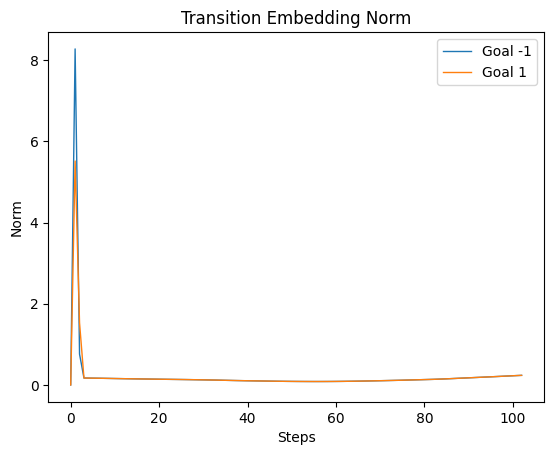

In [11]:
import matplotlib.pyplot as plt

plt.plot(embeddings_norm[0], label='Goal -1', linewidth=1)
plt.plot(embeddings_norm[1], label='Goal 1', linewidth=1)

plt.title('Transition Embedding Norm')
plt.xlabel('Steps')
plt.ylabel('Norm')
plt.legend()
plt.show()

### Cosine Similarity

How much does the memory get affected by uninformative transitions? (Directionwise)

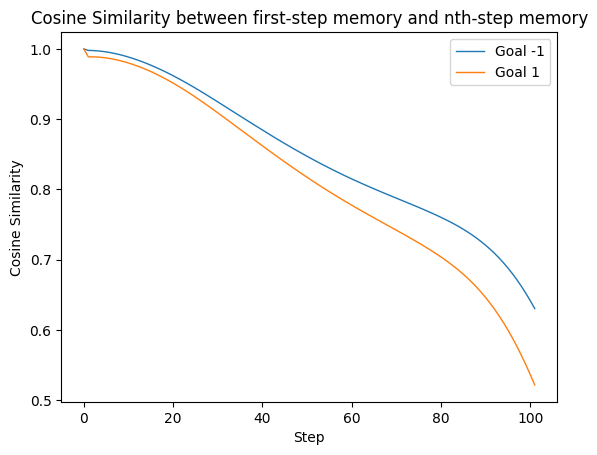

In [12]:
for i, goal_y in enumerate([-1, 1]):
    first_memory = memories[i, 1, :] # (B, hidden_size)
    cos_sim_mean = []
    for j in range(memories.shape[1]):
        if j == 0:
            continue
        else:
            cos_sim_mean.append(np.sum(first_memory * memories[i, j, :]) / memories.shape[2]) # Normalized by hidden_size
    plt.plot(np.array(cos_sim_mean), label=f'Goal {goal_y}', linewidth=1)
plt.title('Cosine Similarity between first-step memory and nth-step memory')
plt.xlabel('Step')
plt.ylabel('Cosine Similarity')
plt.legend()
plt.show()

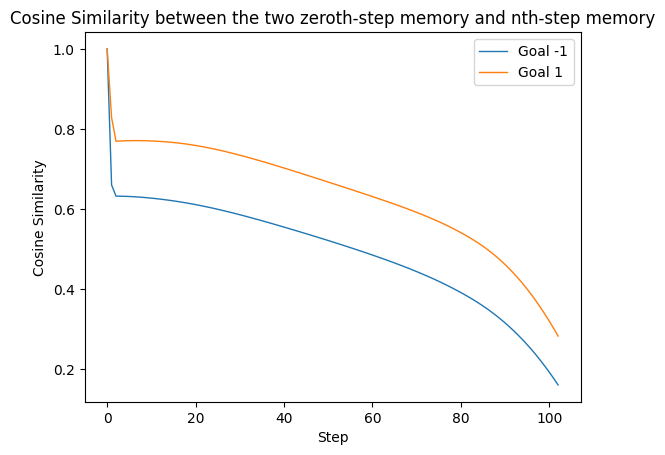

In [13]:
for i, goal_y in enumerate([-1, 1]):
    first_memory = memories[i, 0, :] # (B, hidden_size)
    cos_sim_mean = []
    for j in range(memories.shape[1]):
        cos_sim_mean.append(np.sum(first_memory * memories[i, j, :]) / memories.shape[2]) # Normalized by hidden_size
    plt.plot(np.array(cos_sim_mean), label=f'Goal {goal_y}', linewidth=1)
plt.title('Cosine Similarity between the two zeroth-step memory and nth-step memory')
plt.xlabel('Step')
plt.ylabel('Cosine Similarity')
plt.legend()
plt.show()

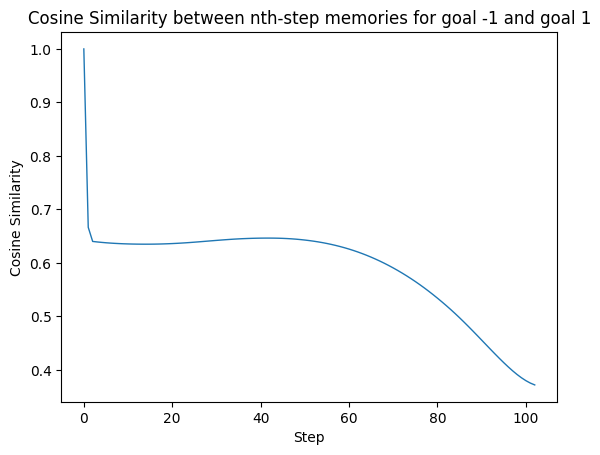

In [15]:
cos_sim_mean = []
for j in range(memories.shape[1]):
    cos_sim_mean.append(np.sum(memories[0, j, :] * memories[1, j, :]) / memories.shape[2]) # Normalized by hidden_size
plt.plot(np.array(cos_sim_mean), linewidth=1)
plt.title('Cosine Similarity between nth-step memories for goal -1 and goal 1')
plt.xlabel('Step')
plt.ylabel('Cosine Similarity')
plt.show()